# Modelling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fontTools.subset import subset
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, roc_auc_score,
                             confusion_matrix)
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
import warnings

from transformers.initialization import default_flax_embed_init_

warnings.filterwarnings('ignore', category=UserWarning, message='.*unknown categories.*')

In [2]:
X = pd.read_csv('../data/processed_data/features_processed/model_features.csv')
y = pd.read_csv('../data/processed_data/features_processed/model_target.csv')
y = y.to_numpy().ravel() # Converting y into a 1D array so it can be used by our models

In [3]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print(f"Training Set Size: {X_train.shape[0]}")
print(f"Testing Set Size: {X_test.shape[0]}")

Training Set Size: 4779
Testing Set Size: 1594


We want to try multiple different models and compare their results.

In [4]:
# Creating a dictionary of classification models to compare
models = {
    'logistic_regression': Pipeline([
        ('classifier', LogisticRegression(random_state=42))
    ]),

    'hist_gradient_boosting': Pipeline([
        ('classifier', HistGradientBoostingClassifier(random_state=42)),
    ]),

    'random_forest': Pipeline([
        ('classifier', RandomForestClassifier(random_state=42))
    ]),

    'gradient_boosting': Pipeline([
        ('classifier', GradientBoostingClassifier(random_state=42))
    ]),

    'decision_tree': Pipeline([
        ('classifier', DecisionTreeClassifier(random_state=42))
    ])
}

Now we will use cross-validation to identify the model with the highest ROC-AUC score (the "best" model)

In [5]:
# Defining the dictionary to store the results of each model
results = {}

# Iterating over each model in the dictionary
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train,
                                cv=5, scoring='roc_auc')
    results[name] = {
        'mean_auc': cv_scores.mean(),
        'std_auc': cv_scores.std()
    }
    print(f"{name}: AUC = {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

# Select best model based on mean AUC
best_model_name = max(results, key=lambda x: results[x]['mean_auc'])
print(f"\nBest model: {best_model_name}")

logistic_regression: AUC = 0.951 (+/- 0.006)
hist_gradient_boosting: AUC = 0.951 (+/- 0.004)
random_forest: AUC = 0.947 (+/- 0.005)
gradient_boosting: AUC = 0.923 (+/- 0.008)
decision_tree: AUC = 0.851 (+/- 0.011)

Best model: hist_gradient_boosting


In [6]:
if best_model_name == 'logistic_regression':
    param_grid = {
        'classifier__C': [0.1, 1, 10],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear', 'saga']
    }
elif best_model_name == 'hist_gradient_boosting':
    param_grid = {
        'classifier__max_iter': [100, 200, 300],
        'classifier__learning_rate': [0.05, 0.1, 0.2],
        'classifier__max_depth': [4, 6, 8],
        'classifier__min_samples_leaf': [20, 50, 100],
        'classifier__l2_regularization': [0, 0.1, 1]
    }
elif best_model_name == 'random_forest':
    param_grid = {
        'classifier__n_estimators': [100, 200, 300],      # Number of trees
        'classifier__max_depth': [5, 10, 15]       # Tree depth (None = unlimited)
    }
elif best_model_name == 'gradient_boosting':
    param_grid = {
        'classifier__learning_rate': [0.05, 0.1],    # Step size for each tree
        'classifier__n_estimators': [100, 200]       # Number of boosting rounds
    }

# Grid search tests all parameter combinations
grid_search = GridSearchCV(
    models[best_model_name],
    param_grid,
    cv=5,                    # 5-fold cross-validation for each combination
    scoring='roc_auc',
    n_jobs=-1,                # Use all CPU cores (faster),
    verbose=1
)

# Fit the grid search
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__l2_regularization': [0, 0.1, ...], 'classifier__learning_rate': [0.05, 0.1, ...], 'classifier__max_depth': [4, 6, ...], 'classifier__max_iter': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more a

In [7]:
# Displaying the best parameters found by the grid search
print(f"Best parameters: {grid_search.best_params_}", "\n")
print(f"Best cross-validation score: {grid_search.best_score_:.3f}")

Best parameters: {'classifier__l2_regularization': 0, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 8, 'classifier__max_iter': 300, 'classifier__min_samples_leaf': 20} 

Best cross-validation score: 0.951


In [8]:
# Get the best model from grid search
best_model = grid_search.best_estimator_

# Make predictions on held-out test set (never seen during training)
y_pred = best_model.predict(X_test)           # Class predictions ('safe' or 'unsafe')
y_proba = best_model.predict_proba(X_test)[:, 1]  # Probability of 'unsafe' class

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# Classification report shows:
# - Precision: Of all predicted unsafe, how many were actually unsafe?
# - Recall: Of all actual unsafe, how many did we catch?
# - F1-score: Harmonic mean of precision and recall
# - Support: Number of samples in each class

print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

Classification Report:

              precision    recall  f1-score   support

        safe       0.91      0.84      0.87       723
      unsafe       0.88      0.93      0.90       871

    accuracy                           0.89      1594
   macro avg       0.89      0.88      0.89      1594
weighted avg       0.89      0.89      0.89      1594

ROC-AUC: 0.957


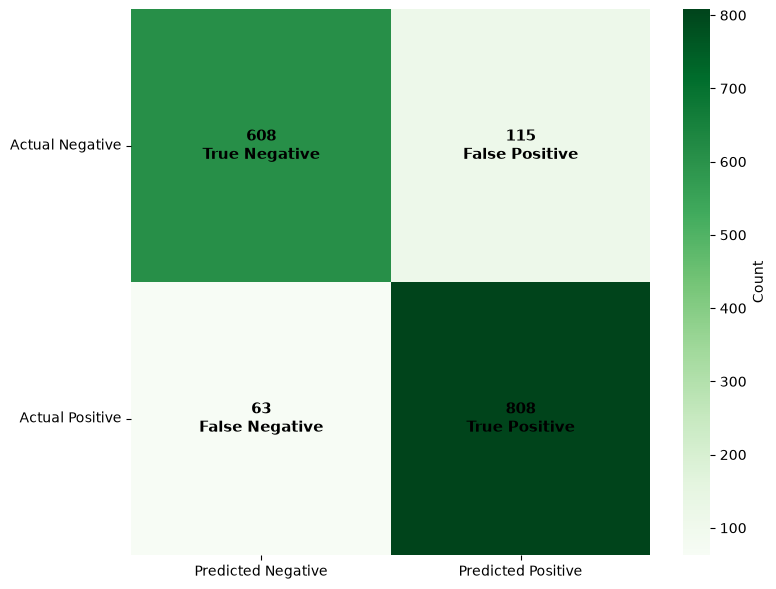

In [9]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=False, fmt='d', cmap='Greens', ax=ax, cbar_kws={"label": "Count"})

labels = {
    (0, 0): ("TN", "True Negative"),
    (0, 1): ("FP", "False Positive"),
    (1, 0): ("FN", "False Negative"),
    (1, 1): ("TP", "True Positive"),
}

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        acronym, full_label = labels[(i, j)]

        # Stack: count → acronym → full label (3 lines)
        text = f"{count}\n{full_label}"

        ax.text(j + 0.5, i + 0.5, text,
                ha="center", va="center", fontsize=11, fontweight="bold", color="black")

ax.set_xticks(np.arange(cm.shape[1]) + 0.5)
ax.set_yticks(np.arange(cm.shape[0]) + 0.5)
ax.set_xticklabels(["Predicted Negative", "Predicted Positive"])
ax.set_yticklabels(["Actual Negative", "Actual Positive"], rotation=0)
plt.tight_layout()
plt.show()

In [10]:
true_positives = cm[1, 1]
false_positives = cm[0, 1]
true_negatives = cm[0, 0]
false_negatives = cm[1, 0]

print("True positives:", true_positives)
print("False positives:", false_positives)
print("True negatives:", true_negatives)
print("False negatives:", false_negatives)

True positives: 808
False positives: 115
True negatives: 608
False negatives: 63


# Minimal Features Model

A critical consideration for a model like this is how accessible will it be and to whom. Therefore we're training a model that has information that is easy to measure or locate: Waterbody Name, Total Length, and Weight. We'll consider if this information produces a model with acceptable predicted vs actual values.

In [11]:
X_mini = pd.read_csv('../data/processed_data/features_processed/model_features_mini.csv')
y_mini = pd.read_csv('../data/processed_data/features_processed/model_target_mini.csv')
y_mini = y_mini.to_numpy().ravel()

In [12]:
X_train_mini, X_test_mini, y_train_mini, y_test_mini = train_test_split(X_mini, y_mini, test_size=0.25, random_state=42, stratify=y)

In [13]:
results_mini = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_mini, y_train_mini,
                                cv=5, scoring='roc_auc')
    results_mini[name] = {
        'mean_auc': cv_scores.mean(),
        'std_auc': cv_scores.std()
    }
    print(f"{name}: AUC = {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

# Select best model based on mean AUC
best_model_name_mini = max(results_mini, key=lambda x: results_mini[x]['mean_auc'])
print(f"\nBest model: {best_model_name_mini}")

logistic_regression: AUC = 0.860 (+/- 0.006)
hist_gradient_boosting: AUC = 0.875 (+/- 0.005)
random_forest: AUC = 0.892 (+/- 0.011)
gradient_boosting: AUC = 0.846 (+/- 0.010)
decision_tree: AUC = 0.774 (+/- 0.014)

Best model: random_forest


In [14]:
if best_model_name_mini == 'logistic_regression':
    param_grid = {
        'classifier__C': [0.1, 1, 10],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear', 'saga']
    }
elif best_model_name_mini == 'hist_gradient_boosting':
    param_grid = {
        'classifier__max_iter': [100, 200, 300],
        'classifier__learning_rate': [0.05, 0.1, 0.2],
        'classifier__max_depth': [4, 6, 8],
        'classifier__min_samples_leaf': [20, 50, 100],
        'classifier__l2_regularization': [0, 0.1, 1]
    }
elif best_model_name_mini == 'random_forest':
    param_grid = {
        'classifier__n_estimators': [100, 200, 300],      # Number of trees
        'classifier__max_depth': [5, 10, 15],      # Tree depth (None = unlimited)
        'classifier__min_samples_leaf': [1, 5, 10],
        'classifier__max_features': ['sqrt', 'log2', None],
        'classifier__bootstrap': [True, False]       # Tree depth (None = unlimited)
    }
elif best_model_name_mini == 'gradient_boosting':
    param_grid = {
        'classifier__learning_rate': [0.05, 0.1],    # Step size for each tree
        'classifier__n_estimators': [100, 200]       # Number of boosting rounds
    }

# Grid search tests all parameter combinations
grid_search_mini = GridSearchCV(
    models[best_model_name_mini],
    param_grid,
    cv=3,                    # 5-fold cross-validation for each combination
    scoring='roc_auc',
    n_jobs=-1,                # Use all CPU cores (faster),
    verbose=1
)

# Fit the grid search
grid_search_mini.fit(X_train_mini, y_train_mini)

Fitting 3 folds for each of 162 candidates, totalling 486 fits


/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__bootstrap': [True, False], 'classifier__max_depth': [5, 10, ...], 'classifier__max_features': ['sqrt', 'log2', ...], 'classifier__min_samples_leaf': [1, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more 

In [15]:
# Get the best model from grid search
best_model_name_mini = grid_search_mini.best_estimator_

# Make predictions on held-out test set (never seen during training)
y_pred_mini = best_model_name_mini.predict(X_test_mini)           # Class predictions ('safe' or 'unsafe')
y_proba_mini = best_model_name_mini.predict_proba(X_test_mini)[:, 1]  # Probability of 'unsafe' class

print("Classification Report:")
print(classification_report(y_test_mini, y_pred_mini))

# Classification report shows:
# - Precision: Of all predicted unsafe, how many were actually unsafe?
# - Recall: Of all actual unsafe, how many did we catch?
# - F1-score: Harmonic mean of precision and recall
# - Support: Number of samples in each class

print(f"ROC-AUC: {roc_auc_score(y_test_mini, y_proba_mini):.3f}")

Classification Report:
              precision    recall  f1-score   support

        safe       0.90      0.50      0.64       723
      unsafe       0.70      0.95      0.81       871

    accuracy                           0.75      1594
   macro avg       0.80      0.73      0.72      1594
weighted avg       0.79      0.75      0.73      1594

ROC-AUC: 0.879


In [16]:
# Navigate to the Random Forest classifier in your pipeline
rf_classifier_mini = best_model_name_mini.named_steps['classifier']

# Extract importances (values sum to 1)
importances_mini = rf_classifier_mini.feature_importances_

# Create a DataFrame for easy viewing
feature_names_mini = X_train_mini.columns  # or whatever your feature names are
importance_df_mini = pd.DataFrame({
    'Feature': feature_names_mini,
    'Importance': importances_mini
}).sort_values('Importance', ascending=False)

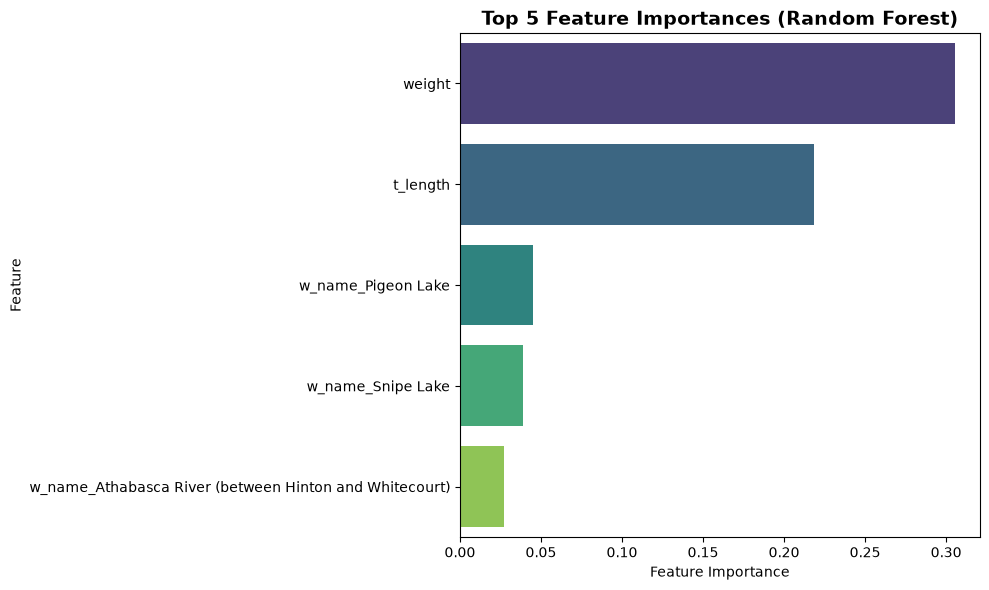

In [17]:
# Set how many features to display
top_n = 5

importance_df_mini = importance_df_mini.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=importance_df_mini,
    x='Importance',       # values on x-axis → horizontal bars
    y='Feature',          # categories on y-axis
    hue='Feature',
    palette='viridis',     # or 'Blues', 'magma', 'cividis', etc.
    legend=False,
)

ax.set_xlabel('Feature Importance')
ax.set_title(f'Top {top_n} Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

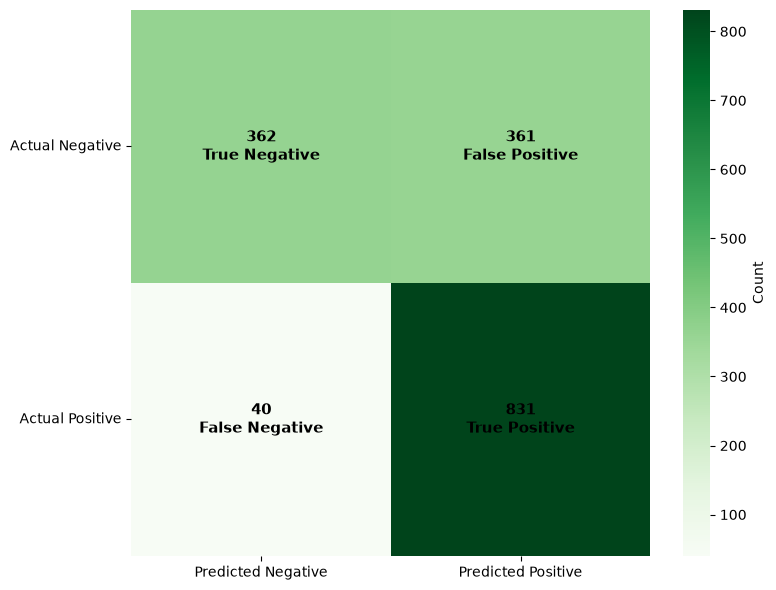

In [18]:
cm_mini = confusion_matrix(y_test_mini, y_pred_mini)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_mini, annot=False, fmt='d', cmap='Greens', ax=ax, cbar_kws={"label": "Count"})

labels = {
    (0, 0): ("TN", "True Negative"),
    (0, 1): ("FP", "False Positive"),
    (1, 0): ("FN", "False Negative"),
    (1, 1): ("TP", "True Positive"),
}

for i in range(cm_mini.shape[0]):
    for j in range(cm_mini.shape[1]):
        count = cm_mini[i, j]
        acronym, full_label = labels[(i, j)]

        # Stack: count → acronym → full label (3 lines)
        text = f"{count}\n{full_label}"

        ax.text(j + 0.5, i + 0.5, text,
                ha="center", va="center", fontsize=11, fontweight="bold", color="black")

ax.set_xticks(np.arange(cm_mini.shape[1]) + 0.5)
ax.set_yticks(np.arange(cm_mini.shape[0]) + 0.5)
ax.set_xticklabels(["Predicted Negative", "Predicted Positive"])
ax.set_yticklabels(["Actual Negative", "Actual Positive"], rotation=0)
plt.tight_layout()
plt.show()

In [19]:
true_positives_mini = cm_mini[1, 1]
false_positives_mini = cm_mini[0, 1]
true_negatives_mini = cm_mini[0, 0]
false_negatives_mini = cm_mini[1, 0]

print("True positives:", true_positives_mini)
print("False positives:", false_positives_mini)
print("True negatives:", true_negatives_mini)
print("False negatives:", false_negatives_mini)

True positives: 831
False positives: 361
True negatives: 362
False negatives: 40


# Bare Model

In [20]:
X_bare = pd.read_csv('../data/processed_data/features_processed/model_features_bare.csv')
y_bare = pd.read_csv('../data/processed_data/features_processed/model_target_bare.csv')
y_bare = y_bare.to_numpy().ravel()

In [21]:
X_train_bare, X_test_bare, y_train_bare, y_test_bare = train_test_split(X_bare, y_bare, test_size=0.25, random_state=42, stratify=y_bare)

In [22]:
models_na_values = {
    'hist_gradient_boosting': Pipeline([
        ('classifier', HistGradientBoostingClassifier(random_state=42)),
    ]),

    'random_forest': Pipeline([
        ('classifier', RandomForestClassifier(random_state=42))
    ]),

    'decision_tree': Pipeline([
        ('classifier', DecisionTreeClassifier(random_state=42))
    ])
}

In [23]:
results_bare = {}
for name, model in models_na_values.items():
    cv_scores = cross_val_score(model, X_train_bare, y_train_bare,
                                cv=5, scoring='roc_auc')
    results_bare[name] = {
        'mean_auc': cv_scores.mean(),
        'std_auc': cv_scores.std()
    }
    print(f"{name}: AUC = {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

# Select best model based on mean AUC
best_model_name_bare = max(results_bare, key=lambda x: results_bare[x]['mean_auc'])
print(f"\nBest model: {best_model_name_bare}")

hist_gradient_boosting: AUC = 0.877 (+/- 0.006)
random_forest: AUC = 0.893 (+/- 0.011)
decision_tree: AUC = 0.779 (+/- 0.014)

Best model: random_forest


In [24]:
if best_model_name_bare == 'logistic_regression':
    param_grid = {
        'classifier__C': [0.1, 1, 10],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear', 'saga']
    }
elif best_model_name_bare == 'hist_gradient_boosting':
    param_grid = {
        'classifier__max_iter': [100, 200, 300],
        'classifier__learning_rate': [0.05, 0.1, 0.2],
        'classifier__max_depth': [4, 6, 8],
        'classifier__min_samples_leaf': [20, 50, 100],
        'classifier__l2_regularization': [0, 0.1, 1]
    }
elif best_model_name_bare == 'random_forest':
    param_grid = {
        'classifier__n_estimators': [100, 200, 300],      # Number of trees
        'classifier__max_depth': [5, 10, 15],      # Tree depth (None = unlimited)
        'classifier__min_samples_leaf': [1, 5, 10],
        'classifier__max_features': ['sqrt', 'log2', None],
        'classifier__bootstrap': [True, False]       # Tree depth (None = unlimited)
    }
elif best_model_name_bare == 'gradient_boosting':
    param_grid = {
        'classifier__learning_rate': [0.05, 0.1],    # Step size for each tree
        'classifier__n_estimators': [100, 200]       # Number of boosting rounds
    }

# Grid search tests all parameter combinations
grid_search_bare = GridSearchCV(
    models[best_model_name_bare],
    param_grid,
    cv=3,                    # 5-fold cross-validation for each combination
    scoring='roc_auc',
    n_jobs=-1,                # Use all CPU cores (faster),
    verbose=1
)

# Fit the grid search
grid_search_bare.fit(X_train_bare, y_train_bare)

Fitting 3 folds for each of 162 candidates, totalling 486 fits


/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__bootstrap': [True, False], 'classifier__max_depth': [5, 10, ...], 'classifier__max_features': ['sqrt', 'log2', ...], 'classifier__min_samples_leaf': [1, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more 

In [25]:
# df_params = pd.DataFrame.from_dict(grid_search.best_params_)

print(f"Best parameters: {grid_search_bare.best_params_}")
print(f"Best cross-validation score: {grid_search_bare.best_score_:.3f}")

Best parameters: {'classifier__bootstrap': True, 'classifier__max_depth': 15, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 300}
Best cross-validation score: 0.867


In [26]:
# Get the best model from grid search
best_model_bare = grid_search_bare.best_estimator_

# Make predictions on held-out test set (never seen during training)
y_pred_bare = best_model_bare.predict(X_test_bare)           # Class predictions ('safe' or 'unsafe')
y_proba_bare = best_model_bare.predict_proba(X_test_bare)[:, 1]  # Probability of 'unsafe' class

print("Classification Report:")
print(classification_report(y_test_bare, y_pred_bare))

# Classification report shows:
# - Precision: Of all predicted unsafe, how many were actually unsafe?
# - Recall: Of all actual unsafe, how many did we catch?
# - F1-score: Harmonic mean of precision and recall
# - Support: Number of samples in each class

print(f"ROC-AUC: {roc_auc_score(y_test_bare, y_proba_bare):.3f}")

Classification Report:
              precision    recall  f1-score   support

        safe       0.91      0.52      0.66       723
      unsafe       0.70      0.96      0.81       871

    accuracy                           0.76      1594
   macro avg       0.81      0.74      0.73      1594
weighted avg       0.80      0.76      0.74      1594

ROC-AUC: 0.881


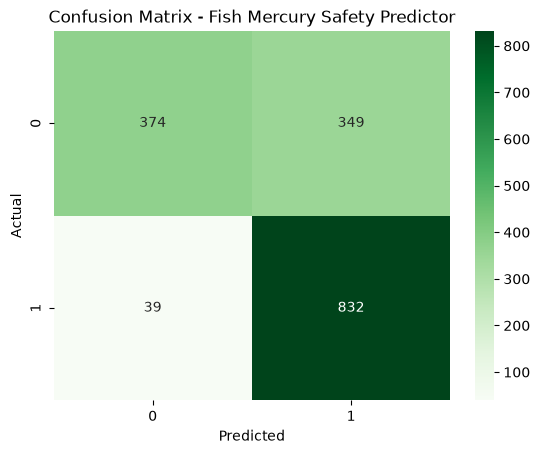

In [27]:
cm_bare = confusion_matrix(y_test_bare, y_pred_bare)

sns.heatmap(cm_bare, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Fish Mercury Safety Predictor')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [28]:
true_positives_bare = cm_bare[1, 1]
false_positives_bare = cm_bare[0, 1]
true_negatives_bare = cm_bare[0, 0]
false_negatives_bare = cm_bare[1, 0]

print("True positives:", true_positives_bare)
print("False positives:", false_positives_bare)
print("True negatives:", true_negatives_bare)
print("False negatives:", false_negatives_bare)

True positives: 832
False positives: 349
True negatives: 374
False negatives: 39


# Complete Model with NaN

In [29]:
X_w_nan= pd.read_csv('../data/processed_data/features_processed/model_features_w_nan.csv')
y_w_nan= pd.read_csv('../data/processed_data/features_processed/model_target_w_nan.csv')
y_w_nan= y_w_nan.to_numpy().ravel()

In [30]:
X_train_w_nan, X_test_w_nan, y_train_w_nan, y_test_w_nan= train_test_split(X_w_nan, y_w_nan, test_size=0.25, random_state=42, stratify=y)

In [31]:
models_na_values = {
    'hist_gradient_boosting': Pipeline([
        ('classifier', HistGradientBoostingClassifier(random_state=42)),
    ]),

    'random_forest': Pipeline([
        ('classifier', RandomForestClassifier(random_state=42))
    ]),

    'decision_tree': Pipeline([
        ('classifier', DecisionTreeClassifier(random_state=42))
    ])
}

In [32]:
results_w_nan= {}
for name, model in models_na_values.items():
    cv_scores = cross_val_score(model, X_train_w_nan, y_train_w_nan,
                                cv=5, scoring='roc_auc')
    results_w_nan[name] = {
        'mean_auc': cv_scores.mean(),
        'std_auc': cv_scores.std()
    }
    print(f"{name}: AUC = {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

# Select best model based on mean AUC
best_model_name_w_nan= max(results_w_nan, key=lambda x: results_w_nan[x]['mean_auc'])
print(f"\nBest model: {best_model_name_w_nan}")

hist_gradient_boosting: AUC = 0.952 (+/- 0.005)
random_forest: AUC = 0.947 (+/- 0.006)
decision_tree: AUC = 0.860 (+/- 0.017)

Best model: hist_gradient_boosting


In [ ]:
if best_model_name_w_nan== 'random_forest':
    param_grid = {
        'classifier__n_estimators': [100, 200, 300],      # Number of trees
        'classifier__max_depth': [5, 10, 15]       # Tree depth (None = unlimited)
    }
elif best_model_name_w_nan== 'gradient_boosting':
    param_grid = {
        'classifier__learning_rate': [0.05, 0.1],    # Step size for each tree
        'classifier__n_estimators': [100, 200]       # Number of boosting rounds
    }
elif best_model_name_w_nan== 'logistic_regression':
    param_grid = {
    'classifier__C': [0.1, 1, 10],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear', 'saga']
}
elif best_model_name_w_nan== 'hist_gradient_boosting':
    param_grid = {
    'classifier__max_iter': [100, 200, 300],
    'classifier__learning_rate': [0.05, 0.1, 0.2],
    'classifier__max_depth': [4, 6, 8],
    'classifier__min_samples_leaf': [20, 50, 100],
    'classifier__l2_regularization': [0, 0.1, 1]
}

# Grid search tests all parameter combinations
grid_search_w_nan= GridSearchCV(
    models[best_model_name_w_nan],
    param_grid,
    cv=5,                    # 5-fold cross-validation for each combination
    scoring='roc_auc',
    n_jobs=-1,                # Use all CPU cores (faster),
    verbose=1
)

# Fit the grid search
grid_search_w_nan.fit(X_train_w_nan, y_train_w_nan)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [ ]:
# df_params = pd.DataFrame.from_dict(grid_search.best_params_)

print(f"Best parameters: {grid_search_w_nan.best_params_}")
print(f"Best cross-validation score: {grid_search_w_nan.best_score_:.3f}")

In [ ]:
# Get the best model from grid search
best_model_w_nan= grid_search_w_nan.best_estimator_

# Make predictions on held-out test set (never seen during training)
y_pred_w_nan= best_model_w_nan.predict(X_test_w_nan)           # Class predictions ('safe' or 'unsafe')
y_proba_w_nan= best_model_w_nan.predict_proba(X_test_w_nan)[:, 1]  # Probability of 'unsafe' class

print("Classification Report:")
print(classification_report(y_test_w_nan, y_pred_w_nan))

# Classification report shows:
# - Precision: Of all predicted unsafe, how many were actually unsafe?
# - Recall: Of all actual unsafe, how many did we catch?
# - F1-score: Harmonic mean of precision and recall
# - Support: Number of samples in each class

print(f"ROC-AUC: {roc_auc_score(y_test_w_nan, y_proba_w_nan):.3f}")

In [ ]:
cm_w_nan= confusion_matrix(y_test_w_nan, y_pred_w_nan)

sns.heatmap(cm_w_nan, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Fish Mercury Safety Predictor')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
true_positives_w_nan= cm_w_nan[1, 1]
false_positives_w_nan= cm_w_nan[0, 1]
true_negatives_w_nan= cm_w_nan[0, 0]
false_negatives_w_nan= cm_w_nan[1, 0]

print("True positives:", true_positives_w_nan)
print("False positives:", false_positives_w_nan)
print("True negatives:", true_negatives_w_nan)
print("False negatives:", false_negatives_w_nan)

# Analysis

In [ ]:
print("The complete information model identified", false_negatives, "false negatives. It identified", false_positives, "false positives.")
print("The complete information model without NaN replacement identified", false_negatives_w_nan, "false negatives. It identified", false_positives_w_nan, "false positives.")
print("The minimal information model identified", false_negatives_mini, "false negatives. It identified", false_positives_mini, "false positives.")
print("The minimal information model without NaN replacement identified", false_negatives_bare, "false negatives. It identified", false_positives_bare, "false positives." )